# Ejercicio 12: Multimodal Embeddings

## Leandro Bravo

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

## Paso 1: Librerías

In [46]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
from transformers import CLIPProcessor, CLIPModel

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import transformers

## Paso 2: Preparación de Datos y Modelo CLIP

In [47]:
# Cargar modelo CLIP

device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 32524.12it/s]


In [48]:
# Cargar imágenes
image_folder = "images"
image_files = sorted(os.listdir(image_folder))

images = [
    Image.open(os.path.join(image_folder, img)).convert("RGB")
    for img in image_files
]

print(image_files)

['Arbol.jpg', 'dab.jpg', 'faro.jpg', 'humano.jpg', 'nube.jpg', 'perro.jpg', 'playa.jpg', 'sol.jpg']


In [49]:
texts = [
    "a pink tree next to a river",
    "a cartoon of a human child doing a dab",
    "A white lighthouse on an island beach",
    "a human man named Cristobal Colon",
    "a cartoon of a sun behind a cloud",
    "a dog",
    "the silhouette of a human on the beach",
    "a caricature of a sun"
]

## Paso 3: Embeddings

In [50]:
# Embeddings de imágenes
inputs = processor(images=images, return_tensors="pt").to(device)

with torch.no_grad():
    vision_outputs = model.vision_model(pixel_values=inputs["pixel_values"])
    image_embeddings = model.visual_projection(vision_outputs.pooler_output)

# Normalización L2
image_embeddings = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

image_embeddings = image_embeddings.cpu().numpy()

In [51]:
# Embeddings de texto
inputs = processor(text=texts, return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    text_outputs = model.text_model(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    )
    text_embeddings = model.text_projection(text_outputs.pooler_output)

# Normalización L2
text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

text_embeddings = text_embeddings.cpu().numpy()

In [52]:
print("Dimensión embeddings de imágenes:", image_embeddings.shape)
print("Dimensión embeddings de texto:", text_embeddings.shape)

Dimensión embeddings de imágenes: (8, 512)
Dimensión embeddings de texto: (8, 512)


## Paso 4: Visualización PCA

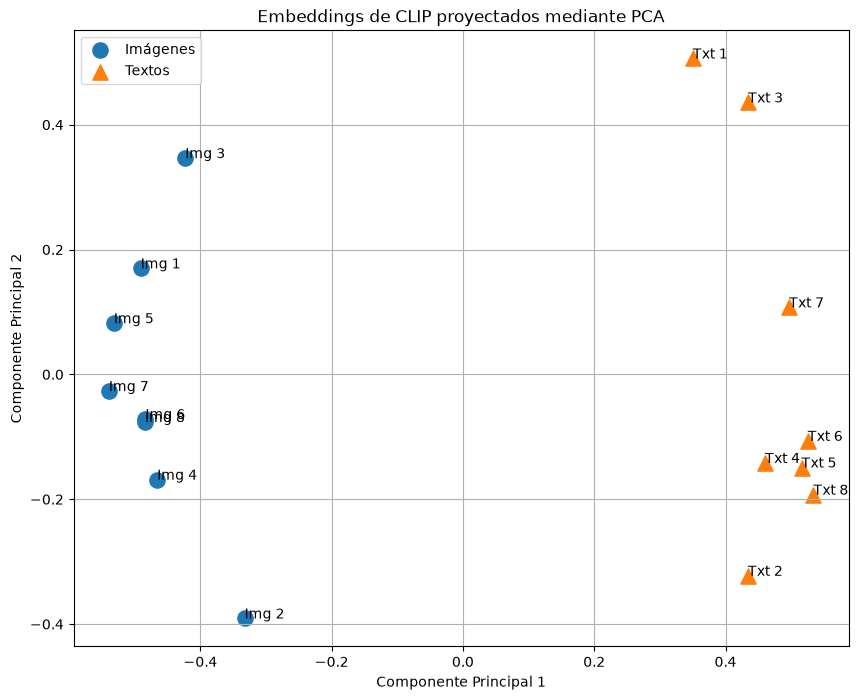

In [53]:
# Unir embeddings
all_embeddings = np.vstack((image_embeddings, text_embeddings))

# Creamos las etiquetas
labels = (
    [f"Img {i+1}" for i in range(len(image_files))]
    +
    [f"Txt {i+1}" for i in range(len(texts))]
)

# Aplicamos PCA
pca = PCA(n_components=2)

embeddings_2d = pca.fit_transform(all_embeddings)

# Graficamos 
plt.figure(figsize=(10,8))

n = len(image_files)

plt.scatter(
    embeddings_2d[:n,0],
    embeddings_2d[:n,1],
    s=120,
    label="Imágenes"
)

plt.scatter(
    embeddings_2d[n:,0],
    embeddings_2d[n:,1],
    marker="^",
    s=120,
    label="Textos"
)

for i, label in enumerate(labels):
    plt.text(
        embeddings_2d[i,0],
        embeddings_2d[i,1],
        label
    )

plt.title("Embeddings de CLIP proyectados mediante PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.grid(True)

plt.show()

## Paso 5: Cosine SImilarity

In [54]:
similarity = cosine_similarity(text_embeddings, image_embeddings)
print(similarity)

[[0.190061   0.0929356  0.17388925 0.11467348 0.14027278 0.09559713
  0.13608097 0.09940286]
 [0.15929385 0.3331731  0.10612483 0.19499817 0.15167138 0.15035076
  0.24088095 0.1624389 ]
 [0.22859709 0.11074175 0.2970662  0.09333586 0.16901751 0.13682312
  0.17149696 0.1390859 ]
 [0.2059833  0.23337793 0.19009963 0.19680992 0.20329347 0.15449968
  0.21019112 0.20068847]
 [0.16525169 0.2063767  0.1657352  0.12681708 0.25378618 0.163436
  0.20737566 0.25292027]
 [0.18017615 0.23487386 0.1735331  0.18179658 0.19394836 0.24809319
  0.18555436 0.19611445]
 [0.2185122  0.13809656 0.2016311  0.18264656 0.2059429  0.14106947
  0.24459204 0.19375701]
 [0.18842234 0.22186339 0.16423516 0.18964735 0.20522273 0.185991
  0.21260801 0.30628502]]


In [55]:
print("Texto -> Imagen\n")

for i, text in enumerate(texts):

    idx = np.argmax(similarity[i])

    print(f'Texto: "{text}"')
    print(f"Imagen encontrada: {image_files[idx]}")
    print(f"Similitud: {similarity[i, idx]:.4f}")
    print()

Texto -> Imagen

Texto: "a pink tree next to a river"
Imagen encontrada: Arbol.jpg
Similitud: 0.1901

Texto: "a cartoon of a human child doing a dab"
Imagen encontrada: dab.jpg
Similitud: 0.3332

Texto: "A white lighthouse on an island beach"
Imagen encontrada: faro.jpg
Similitud: 0.2971

Texto: "a human man named Cristobal Colon"
Imagen encontrada: dab.jpg
Similitud: 0.2334

Texto: "a cartoon of a sun behind a cloud"
Imagen encontrada: nube.jpg
Similitud: 0.2538

Texto: "a dog"
Imagen encontrada: perro.jpg
Similitud: 0.2481

Texto: "the silhouette of a human on the beach"
Imagen encontrada: playa.jpg
Similitud: 0.2446

Texto: "a caricature of a sun"
Imagen encontrada: sol.jpg
Similitud: 0.3063



In [56]:
similarity_inv = cosine_similarity(image_embeddings, text_embeddings)

print("Imagen -> Texto\n")

for i, image in enumerate(image_files):

    idx = np.argmax(similarity_inv[i])

    print(f"Imagen: {image}")
    print(f"Texto encontrado: {texts[idx]}")
    print(f"Similitud: {similarity_inv[i, idx]:.4f}")
    print()

Imagen -> Texto

Imagen: Arbol.jpg
Texto encontrado: A white lighthouse on an island beach
Similitud: 0.2286

Imagen: dab.jpg
Texto encontrado: a cartoon of a human child doing a dab
Similitud: 0.3332

Imagen: faro.jpg
Texto encontrado: A white lighthouse on an island beach
Similitud: 0.2971

Imagen: humano.jpg
Texto encontrado: a human man named Cristobal Colon
Similitud: 0.1968

Imagen: nube.jpg
Texto encontrado: a cartoon of a sun behind a cloud
Similitud: 0.2538

Imagen: perro.jpg
Texto encontrado: a dog
Similitud: 0.2481

Imagen: playa.jpg
Texto encontrado: the silhouette of a human on the beach
Similitud: 0.2446

Imagen: sol.jpg
Texto encontrado: a caricature of a sun
Similitud: 0.3063



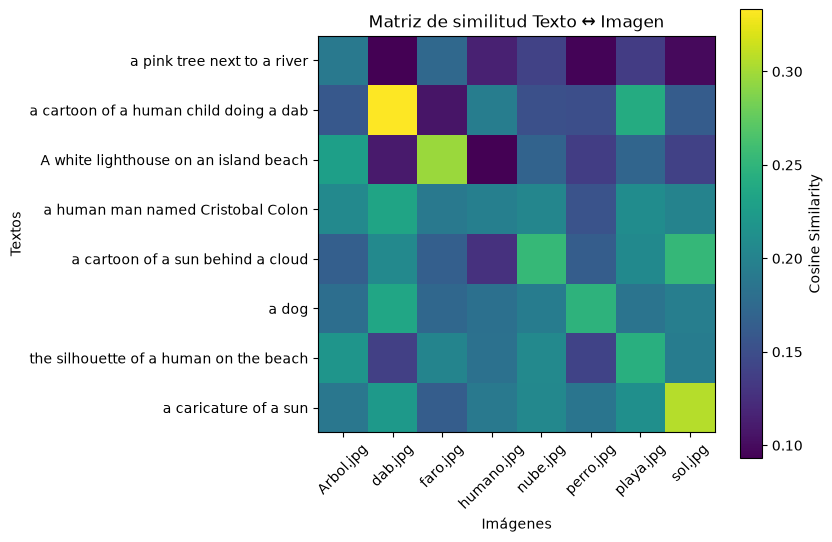

In [57]:
plt.figure(figsize=(8,6))

plt.imshow(similarity, cmap="viridis")
plt.colorbar(label="Cosine Similarity")

plt.xticks(range(len(image_files)), image_files, rotation=45)
plt.yticks(range(len(texts)), texts)

plt.xlabel("Imágenes")
plt.ylabel("Textos")
plt.title("Matriz de similitud Texto ↔ Imagen")

plt.tight_layout()
plt.show()

## Paso 6: Búsqueda

In [58]:
def buscar(query, top_k=3):

    inputs = processor(
        text=[query],
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        text_outputs = model.text_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )

        query_embedding = model.text_projection(text_outputs.pooler_output)

    # Normalizar
    query_embedding = query_embedding / query_embedding.norm(dim=-1, keepdim=True)

    query_embedding = query_embedding.cpu().numpy()

    # Similaridades
    sim_images = cosine_similarity(query_embedding, image_embeddings)[0]
    sim_texts = cosine_similarity(query_embedding, text_embeddings)[0]

    # Top resultados
    top_images = np.argsort(sim_images)[::-1][:top_k]
    top_texts = np.argsort(sim_texts)[::-1][:top_k]

    print("\nConsulta:", query)

    print("\nImágenes más similares\n")

    for idx in top_images:
        print(f"{image_files[idx]}  ({sim_images[idx]:.4f})")

    print("\nTextos más similares\n")

    for idx in top_texts:
        print(f"{texts[idx]}  ({sim_texts[idx]:.4f})")

    # Mostrar mejor imagen
    mejor = top_images[0]

    plt.figure(figsize=(15,5))

    for i, idx in enumerate(top_images):

        plt.subplot(1, top_k, i+1)
        plt.imshow(images[idx])
        plt.axis("off")
        plt.title(f"{sim_images[idx]:.3f}")

    plt.tight_layout()
    plt.show()


Consulta: dog and a river

Imágenes más similares

perro.jpg  (0.2039)
faro.jpg  (0.1626)
nube.jpg  (0.1616)

Textos más similares

a dog  (0.8164)
the silhouette of a human on the beach  (0.6353)
a caricature of a sun  (0.6234)


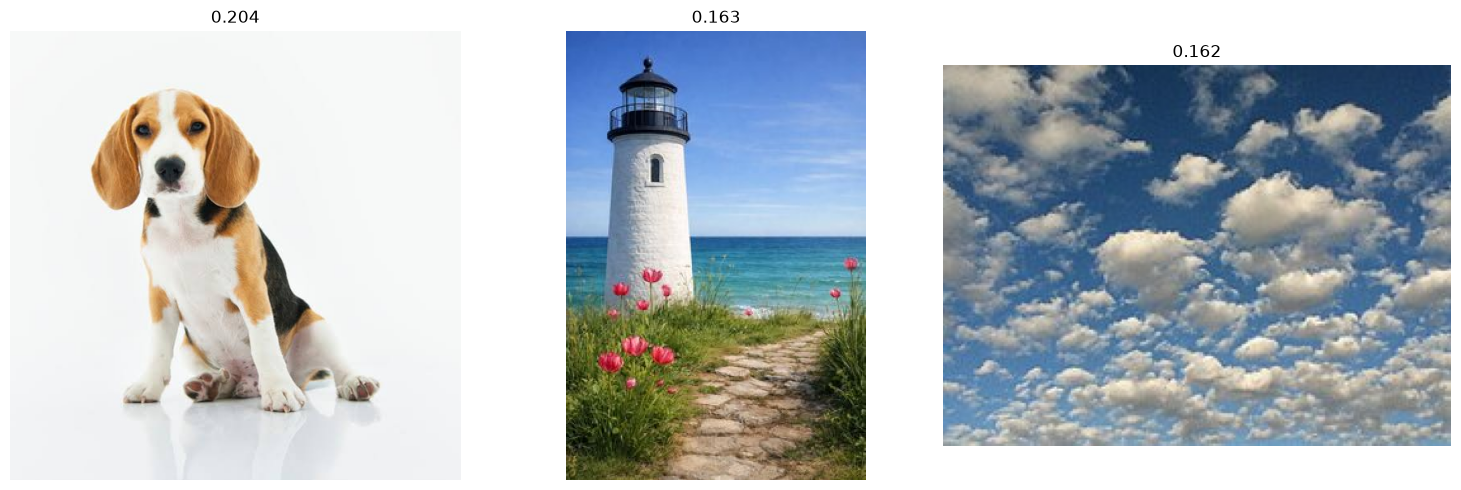

In [59]:
buscar("dog and a river")